# Lecture 7: Regression Algorithms and Clustering
**BITE 485 | Tharaka University**

---

## Learning Outcomes
1. Apply Ridge and Lasso regression and compare with OLS
2. Implement K-Means clustering with the elbow method
3. Implement hierarchical clustering and read a dendrogram
4. Evaluate clustering quality with silhouette score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
print('Ready.')

Ready.


## 7.1 Regression Comparison: OLS vs Ridge vs Lasso

**Scenario:** Predict housing rent in Nairobi from property features.

In [2]:
np.random.seed(42)
n = 400
bedrooms  = np.random.randint(1, 6, n)
sqm       = np.random.normal(80, 30, n).clip(20, 250)
floor     = np.random.randint(0, 20, n)
dist_cbd  = np.random.uniform(1, 30, n)
age       = np.random.randint(0, 40, n)
rent = (8000 + 6000*bedrooms + 150*sqm - 200*dist_cbd
        - 100*age + 300*floor + np.random.normal(0, 5000, n))
rent = rent.clip(5000, None)

df = pd.DataFrame({'bedrooms': bedrooms, 'sqm': sqm, 'floor': floor,
                   'dist_cbd': dist_cbd, 'age': age, 'rent_kes': rent})

X = df.drop(columns='rent_kes')
y = df['rent_kes']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

results = []
for name, model in [('OLS Linear', LinearRegression()),
                    ('Ridge (a=10)', Ridge(alpha=10)),
                    ('Lasso (a=100)', Lasso(alpha=100))]:
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    results.append({'Model': name,
                    'RMSE': mean_squared_error(y_te, y_pred)**0.5,
                    'R2': r2_score(y_te, y_pred)})

pd.DataFrame(results)

,Model,RMSE,R2
0,OLS Linear,5279.534126,0.815311
1,Ridge (a=10),5278.724841,0.815368
2,Lasso (a=100),5279.686336,0.815301


## 7.2 K-Means Clustering

**Scenario:** Segment Nairobi shoppers by spending behaviour.

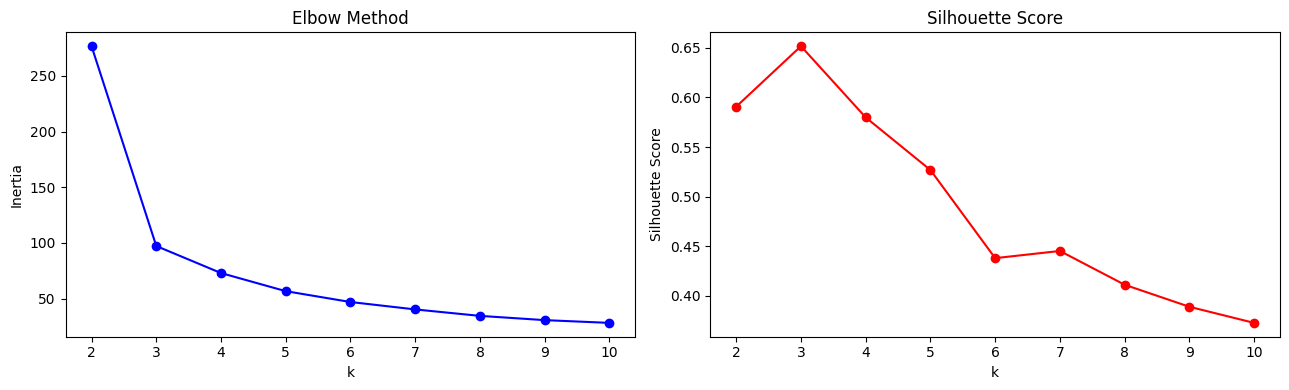

In [3]:
np.random.seed(42)
# Three natural customer groups
group_a = np.random.multivariate_normal([20000, 5], [[4000000,0],[0,2]], 150)   # high spend, few visits
group_b = np.random.multivariate_normal([5000, 15], [[500000,0],[0,4]], 200)   # low spend, frequent
group_c = np.random.multivariate_normal([12000, 10], [[2000000,0],[0,3]], 150) # medium
data = np.vstack([group_a, group_b, group_c])
df_cust = pd.DataFrame(data, columns=['monthly_spend_kes', 'visits_per_month'])

scaler = StandardScaler()
X_sc = scaler.fit_transform(df_cust)

# Elbow method
inertias, silhouettes = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sc, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
plt.tight_layout()
plt.show()

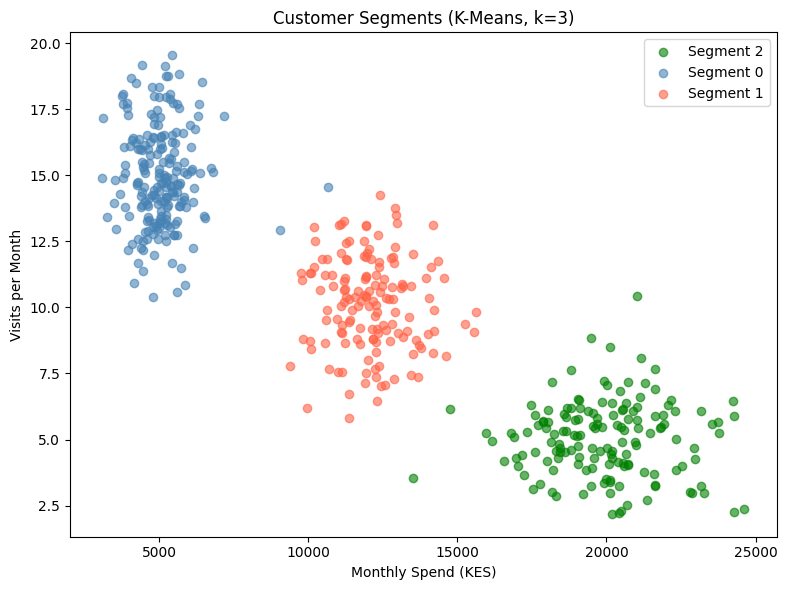

         monthly_spend_kes  visits_per_month
segment                                     
0                   5046.0              15.0
1                  12102.0              10.0
2                  19932.0               5.0


In [4]:
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cust['segment'] = km3.fit_predict(X_sc)

plt.figure(figsize=(8, 6))
colors = {0: 'steelblue', 1: 'tomato', 2: 'green'}
for seg in df_cust.segment.unique():
    sub = df_cust[df_cust.segment == seg]
    plt.scatter(sub.monthly_spend_kes, sub.visits_per_month,
                label=f'Segment {seg}', alpha=0.6, color=colors[seg])
plt.xlabel('Monthly Spend (KES)')
plt.ylabel('Visits per Month')
plt.title('Customer Segments (K-Means, k=3)')
plt.legend()
plt.tight_layout()
plt.show()

print(df_cust.groupby('segment')[['monthly_spend_kes','visits_per_month']].mean().round(0))

## 7.3 Hierarchical Clustering

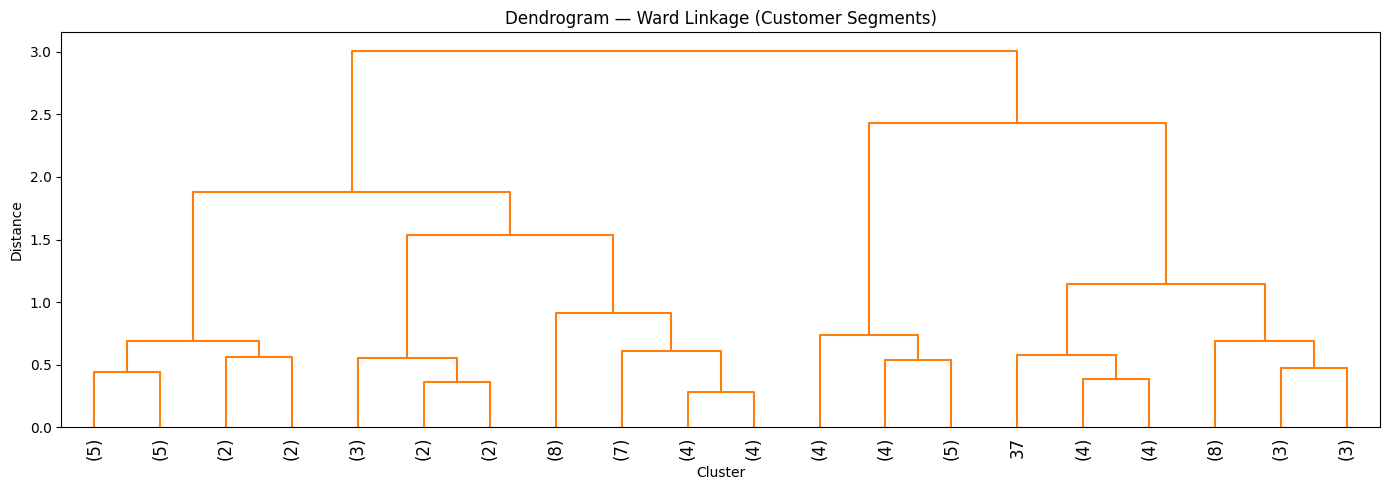

In [5]:
# Use a subset for visualisation
subset = X_sc[:80]
Z = linkage(subset, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=90,
           color_threshold=5, above_threshold_color='grey')
plt.title('Dendrogram — Ward Linkage (Customer Segments)')
plt.xlabel('Cluster')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [6]:
hier = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_cust['hier_segment'] = hier.fit_predict(X_sc)

# Agreement between K-Means and hierarchical
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df_cust['segment'], df_cust['hier_segment'])
print(f'Adjusted Rand Index (K-Means vs Hierarchical): {ari:.4f}')
print('(1.0 = perfect agreement, 0 = random agreement)')

Adjusted Rand Index (K-Means vs Hierarchical): 0.9876
(1.0 = perfect agreement, 0 = random agreement)


### Exercise

Using the customer DataFrame `df_cust`:

1. Try K-Means with k=4 and k=5. Calculate silhouette scores for each.
2. Compare the cluster profiles (mean spend and visits) for k=3 vs k=4. Does the extra segment reveal a meaningful new group?
3. Rename the 3 segments based on their profiles (e.g. 'High Spenders', 'Frequent Visitors', 'Moderate').
4. Create a horizontal bar chart showing average monthly spend per named segment.

K=4 Silhouette Score: 0.5799
K=5 Silhouette Score: 0.5268

Cluster Profiles (K=3):
           monthly_spend_kes  visits_per_month
cluster_3                                     
0                5045.607691         14.954642
1               12101.752175         10.153171
2               19931.878829          5.032475

Cluster Profiles (K=4):
           monthly_spend_kes  visits_per_month
cluster_4                                     
0               19931.878829          5.032475
1               12101.752175         10.153171
2                4951.767765         16.927297
3                5103.413085         13.739486

K=3 Cluster Summary:
         monthly_spend_kes  visits_per_month
cluster                                     
0              5045.607691         14.954642
1             12101.752175         10.153171
2             19931.878829          5.032475

Cluster Naming:
         monthly_spend_kes  visits_per_month       segment_name
cluster                                        

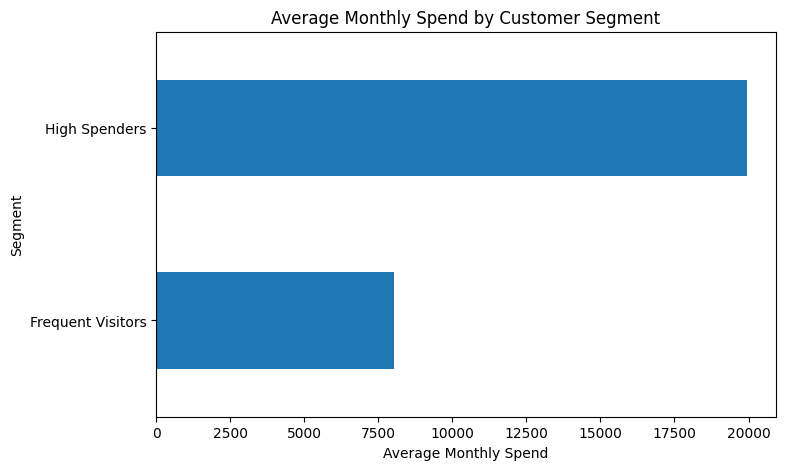

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Prepare data
# -----------------------------
# Correct column names to match df_cust
features = df_cust[['monthly_spend_kes', 'visits_per_month']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# -----------------------------
# 2. K = 4 and K = 5 silhouette scores
# -----------------------------
for k in [4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k} Silhouette Score: {score:.4f}")

# -----------------------------
# 3. Compare K=3 vs K=4 cluster profiles
# -----------------------------
def get_profiles(k):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    df_cust[f'cluster_{k}'] = model.fit_predict(X_scaled)
    # Correct column names
    return df_cust.groupby(f'cluster_{k}')[['monthly_spend_kes', 'visits_per_month']].mean()

profiles_k3 = get_profiles(3)
profiles_k4 = get_profiles(4)

print("\nCluster Profiles (K=3):")
print(profiles_k3)

print("\nCluster Profiles (K=4):")
print(profiles_k4)

# -----------------------------
# 4. Interpret K=3 and assign names
# -----------------------------
k3_model = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cust['cluster'] = k3_model.fit_predict(X_scaled)

# Correct column names
cluster_summary = df_cust.groupby('cluster')[['monthly_spend_kes', 'visits_per_month']].mean()
print("\nK=3 Cluster Summary:")
print(cluster_summary)

# Manually naming based on typical patterns
def name_cluster(row):
    # Correct column names
    if row['monthly_spend_kes'] > cluster_summary['monthly_spend_kes'].mean() and row['visits_per_month'] > cluster_summary['visits_per_month'].mean():
        return "High Value Customers"
    # Correct column names
    elif row['visits_per_month'] > cluster_summary['visits_per_month'].mean():
        return "Frequent Visitors"
    # Correct column names
    elif row['monthly_spend_kes'] > cluster_summary['monthly_spend_kes'].mean():
        return "High Spenders"
    else:
        return "Moderate Customers"

cluster_map = cluster_summary.copy()
cluster_map['segment_name'] = cluster_map.apply(name_cluster, axis=1)

print("\nCluster Naming:")
print(cluster_map)

df_cust['segment'] = df_cust['cluster'].map(cluster_map['segment_name'])

# -----------------------------
# 5. Bar chart: average monthly spend per segment
# -----------------------------
# Correct column name
segment_spend = df_cust.groupby('segment')['monthly_spend_kes'].mean().sort_values()

plt.figure(figsize=(8, 5))
segment_spend.plot(kind='barh')
plt.title('Average Monthly Spend by Customer Segment')
plt.xlabel('Average Monthly Spend')
plt.ylabel('Segment')
plt.show()

---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*